<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# **Random Forest**

Random Forest es un ensamblado de muchos árboles de decisión.  
Su idea es combinar árboles distintos para lograr:
- mejor capacidad predictiva,
- más estabilidad,
- menos sobreajuste que un árbol individual.

## Idea intuitiva
En lugar de confiar en un solo árbol, confiamos en la “votación” de muchos árboles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.datasets import make_classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier


import category_encoders as ce

## 1. Cómo funciona

Cada árbol del bosque se entrena:
- sobre una muestra bootstrap de los datos,
- usando solo un subconjunto aleatorio de variables en cada división.

Eso introduce diversidad entre árboles.  
Luego, el bosque agrega las predicciones:
- promedio de probabilidades,
- voto mayoritario en clasificación.

In [2]:
data = pd.read_csv("dataset_bancario_clean.csv")
df = data.copy()

In [3]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [5]:
X = df.drop(columns="default")

encoder = ce.OrdinalEncoder(cols=cat_cols)
X = encoder.fit_transform(X)

y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## 2. Comparación rápida: árbol único vs random forest

In [6]:
arbol_incicial = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

In [7]:
for name, model in [("Tree", arbol_incicial), ("RandomForest", rf)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(name)
    print("  Accuracy :", round(accuracy_score(y_test, pred), 4))
    print("  F1       :", round(f1_score(y_test, pred), 4))
    print("  ROC AUC  :", round(roc_auc_score(y_test, proba), 4))

Tree
  Accuracy : 0.9856
  F1       : 0.1818
  ROC AUC  : 0.5495
RandomForest
  Accuracy : 0.988
  F1       : 0.0
  ROC AUC  : 0.7599


## 3. Número de árboles (`n_estimators`)

In [8]:
rows = []
for n in [10, 50, 100, 200, 300, 500]:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({"n_estimators": n, "roc_auc": roc_auc_score(y_test, proba)})
pd.DataFrame(rows)

,n_estimators,roc_auc
0,10,0.721242
1,50,0.776383
2,100,0.754791
3,200,0.778084
4,300,0.774845
5,500,0.780108


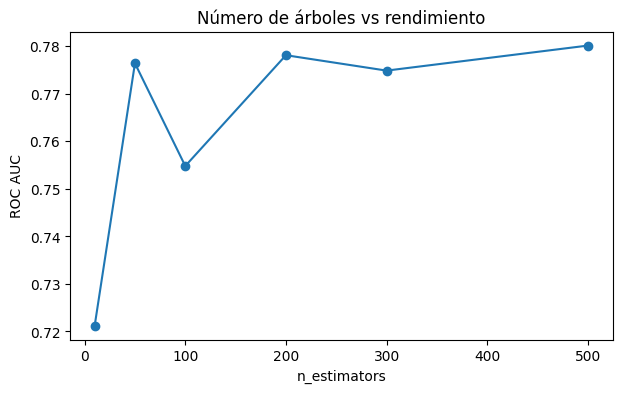

In [9]:
rf_curve = pd.DataFrame(rows)
plt.figure(figsize=(7, 4))
plt.plot(rf_curve["n_estimators"], rf_curve["roc_auc"], marker="o")
plt.xlabel("n_estimators")
plt.ylabel("ROC AUC")
plt.title("Número de árboles vs rendimiento")
plt.show()

## 4. Hiperparámetros principales

- `n_estimators`: número de árboles
- `max_depth`: profundidad máxima
- `min_samples_leaf`: mínimo por hoja
- `max_features`: número de variables candidatas por split
- `bootstrap`: usar o no bootstrap

En general:
- más árboles => más estabilidad,
- árboles demasiado profundos => más complejidad,
- `max_features` más pequeño => más diversidad entre árboles.

In [10]:
configs = [
    {"max_depth": None, "max_features": "sqrt"},
    {"max_depth": 5, "max_features": "sqrt"},
    {"max_depth": 10, "max_features": "sqrt"},
    {"max_depth": 5, "max_features": 0.5},
]

rows = []
for cfg in configs:
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        **cfg
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        **cfg,
        "roc_auc": roc_auc_score(y_test, proba),
        "accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(rows)

,max_depth,max_features,roc_auc,accuracy
0,NaN,sqrt,0.774845,0.9880
1,5.0,sqrt,0.759892,0.9880
2,10.0,sqrt,0.738462,0.9880
3,5.0,0.5,0.744993,0.9872


## 5. Importancia de variables

Hay dos formas comunes:
- importancia interna del bosque (`feature_importances_`),
- importancia por permutación (`permutation_importance`).

In [11]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

imp = pd.DataFrame({
    "variable": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

imp.head(15)

,variable,importance
30,score_interno,0.125432
15,porcentaje_ahorro,0.064962
3,ingresos_mensuales,0.057865
14,utilizacion_credito,0.053265
10,saldo_medio_3m,0.051882
2,antiguedad_cliente,0.050684
12,deuda_total,0.049320
23,uso_banca_digital,0.048073
11,limite_credito,0.048012
16,ratio_endeudamiento,0.047783


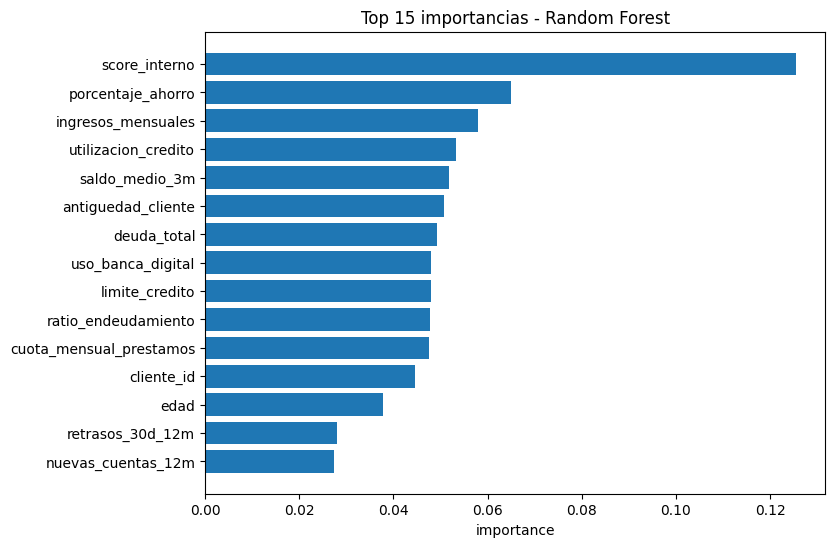

In [12]:
plt.figure(figsize=(8, 6))
top_imp = imp.head(15).sort_values("importance")
plt.barh(top_imp["variable"], top_imp["importance"])
plt.title("Top 15 importancias - Random Forest")
plt.xlabel("importance")
plt.show()

In [13]:
perm = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "variable": X.columns,
    "perm_importance": perm.importances_mean
}).sort_values("perm_importance", ascending=False)

perm_df.head(15)

,variable,perm_importance
13,cuota_mensual_prestamos,0.00024
12,deuda_total,0.00008
3,ingresos_mensuales,0.00008
2,antiguedad_cliente,0.00000
4,situacion_laboral,0.00000
1,edad,0.00000
0,cliente_id,0.00000
6,nivel_estudios,0.00000
5,estado_civil,0.00000
7,provincia_riesgo,0.00000


## 6. OOB score

Si usamos bootstrap, Random Forest puede estimar el rendimiento con observaciones “out-of-bag” sin hacer validación aparte.

In [14]:
rf_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)
print("OOB score:", rf_oob.oob_score_)

OOB score: 0.9874666666666667


## 7. Ventajas y limitaciones

### Ventajas
- Rendimiento alto en muchos problemas tabulares.
- Más robusto que un árbol único.
- Capta no linealidades e interacciones.
- Requiere poca preparación relativa de datos.

### Limitaciones
- Menos interpretable que un árbol individual.
- Importancias pueden ser engañosas si no se revisan bien.
- Más coste computacional.

## 8. Ejercicios propuestos

### Ejercicio 1
Entrena un random forest con 100 árboles y calcula accuracy, F1 y ROC AUC.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 2
Compara un árbol único y un random forest con la misma profundidad máxima.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 3
Prueba n_estimators = 50, 100, 300 y 500.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 4
Prueba max_depth = 3, 5, 10 y None.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 5
Prueba min_samples_leaf = 1, 5 y 10.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 6
Calcula la importancia de variables con feature_importances_.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 7
Calcula la importancia por permutación y compara con la interna.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 8
Entrena un random forest con oob_score=True e interpreta el resultado.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 9
Haz validación cruzada de 5 folds con scoring='roc_auc'.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 10
Explica en qué casos preferirías random forest frente a un árbol individual.

In [ ]:
# Escribe aquí tu solución

# Solucionario

In [ ]:
# Solución 1
rf100 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf100.fit(X_train, y_train)
pred = rf100.predict(X_test)
proba = rf100.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

In [ ]:
# Solución 2
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42, n_jobs=-1)

for name, model in [("Tree", tree), ("RF", rf)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(name, accuracy_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba))

In [ ]:
# Solución 3
for n in [50, 100, 300, 500]:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    print(n, roc_auc_score(y_test, proba))

In [ ]:
# Solución 4
for d in [3, 5, 10, None]:
    model = RandomForestClassifier(n_estimators=300, max_depth=d, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    print(d, roc_auc_score(y_test, proba))

In [ ]:
# Solución 5
for leaf in [1, 5, 10]:
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    print(leaf, roc_auc_score(y_test, proba))

In [ ]:
# Solución 6
imp = pd.DataFrame({
    "variable": X.columns,
    "importance": rf100.feature_importances_
}).sort_values("importance", ascending=False)
imp.head(10)

In [ ]:
# Solución 7
perm = permutation_importance(rf100, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "variable": X.columns,
    "perm_importance": perm.importances_mean
}).sort_values("perm_importance", ascending=False)
perm_df.head(10)

In [ ]:
# Solución 8
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True, bootstrap=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)
rf_oob.oob_score_

In [ ]:
# Solución 9
scores = cross_val_score(
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="roc_auc"
)
print(scores)
print(scores.mean())

In [ ]:
# Solución 10
print("Preferiría random forest cuando priorizo capacidad predictiva y robustez.")
print("Preferiría árbol individual cuando la interpretabilidad regla a regla sea prioritaria.")